# Lineage Construction by Simulated Annealing

This notebook walks through the complete pipeline for reconstructing a **cell lineage forest** from a time-lapse microscopy sequence.

## The biological problem

At a given stage of development, a population of cells divides according to a precise pattern — each cell follows its own **lineage tree**, and together they form a **lineage forest**. Each cell divides into two daughters at a specific time, following a reproducible pattern across individuals. Our goal is to recover that forest automatically from 3-D image stacks.

We focus on a particular **stage of development** in which every cell divides exactly once — so the population doubles over the observed window. The raw measurements for each cell are:
- **centroid** (3-D position)
- **volume**
- **shape descriptors** (solidity, sphericity, aspect ratio)
- **mean intensity**

## The approach: Simulated Annealing

We model the lineage forest as a **balanced binary forest** — each cell at the start is the root of its own tree, and every root eventually splits into 2 leaves. The assignment problem is: *which cell in frame t is the parent of which cell in frame t+1?*

**Simulated annealing (SA)** randomly swaps pairs of assignments and accepts bad moves occasionally (with probability $e^{-\Delta E / T}$, where $T$ cools over time). This lets the optimiser escape local minima and find a globally good lineage forest.

The **cost function** penalises:
- Large centroid displacements between parent and daughter
- Asymmetric splits (daughters should be similar in volume)
- Non-equatorial division angles (daughters should be ~156° apart)
- Volume changes incompatible with cell division

In [1]:
import sys, os, json, math, copy, io, contextlib
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.gridspec as gridspec
import yaml

# ── fixed paths ───────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_DIR  = os.path.dirname(NOTEBOOK_DIR)
COMPUTE_DIR  = os.path.join(PROJECT_DIR, 'ComputeLineage')
CHECK_DIR    = os.path.join(PROJECT_DIR, 'CheckResults')

for d in (COMPUTE_DIR, CHECK_DIR):
    if d not in sys.path:
        sys.path.insert(0, d)

import sim_anneal
from NewCostFunction   import MyCostParams, GeneralCostFunc
from sim_anneal_utils  import (tracksInit, tracksInitFromGT, tracksInitFromSimGraph,
                                GetNucleiPerFrame, OutputGraph, Eval)
from EvaluateCost      import EvaluateSimCost, EvaluateCost
from plot_lineage      import build_layout, assign_root_colors, draw_lineage
from check_splits      import plot_division, find_division_frames

print('Imports OK')

Imports OK


## Configuration

**Edit the cell below before running anything else.**

<table style="border-collapse:collapse; margin-top:8px">
<thead><tr>
  <th style="text-align:left; padding:4px 10px; border-bottom:2px solid #888"><code>CONFIG</code></th>
  <th style="text-align:left; padding:4px 10px; border-bottom:2px solid #888">Dataset</th>
  <th style="text-align:left; padding:4px 10px; border-bottom:2px solid #888">Stage</th>
  <th style="text-align:left; padding:4px 10px; border-bottom:2px solid #888">Frame sampling</th>
</tr></thead>
<tbody>
<tr><td style="padding:3px 10px"><code>'Mouse_8to16'</code></td><td style="padding:3px 10px">Mouse</td><td style="padding:3px 10px">8→16</td><td style="padding:3px 10px">every frame</td></tr>
<tr><td style="padding:3px 10px"><code>'Mouse_8to16_step2'</code></td><td style="padding:3px 10px">Mouse</td><td style="padding:3px 10px">8→16</td><td style="padding:3px 10px">every other frame</td></tr>
<tr><td style="padding:3px 10px"><code>'Mouse_16to32'</code></td><td style="padding:3px 10px">Mouse</td><td style="padding:3px 10px">16→32</td><td style="padding:3px 10px">every frame</td></tr>
<tr><td style="padding:3px 10px"><code>'Mouse_32to64'</code></td><td style="padding:3px 10px">Mouse</td><td style="padding:3px 10px">32→64</td><td style="padding:3px 10px">every frame</td></tr>
<tr><td style="padding:3px 10px"><code>'Worm'</code></td><td style="padding:3px 10px">C. elegans</td><td style="padding:3px 10px">—</td><td style="padding:3px 10px">every frame</td></tr>
<tr><td style="padding:3px 10px"><code>'Worm_step2'</code></td><td style="padding:3px 10px">C. elegans</td><td style="padding:3px 10px">—</td><td style="padding:3px 10px">every other frame</td></tr>
</tbody>
</table>

After editing, use **Run All Cells** (or restart the kernel and run all).


In [2]:
# ═══════════════════════════════════════════════════════════════════
#  USER CONFIGURATION — edit these lines, then Run All Cells
# ═══════════════════════════════════════════════════════════════════

CONFIG = 'Mouse_8to16'    # choose from the table above

# ── Load saved SA result instead of running ────────────────────────────────────────────
USE_PRECOMPUTED = False   # True → load saved sim_graph (if one exists)


In [3]:
_PRESETS = {
    'Mouse_8to16':       dict(DATASET='Mouse', STAGE='8to16',  FRAME_STEP=1),
    'Mouse_8to16_step2': dict(DATASET='Mouse', STAGE='8to16',  FRAME_STEP=2),
    'Mouse_16to32':      dict(DATASET='Mouse', STAGE='16to32', FRAME_STEP=1),
    'Mouse_32to64':      dict(DATASET='Mouse', STAGE='32to64', FRAME_STEP=1),
    'Worm':              dict(DATASET='Worm',  FRAME_STEP=1),
    'Worm_step2':        dict(DATASET='Worm',  FRAME_STEP=2),
}
if CONFIG not in _PRESETS:
    raise ValueError(f'Unknown CONFIG {CONFIG!r}. Valid options: {list(_PRESETS)}')
_p         = _PRESETS[CONFIG]
DATASET    = _p['DATASET']
STAGE      = _p.get('STAGE')
FRAME_STEP = _p['FRAME_STEP']

_MOUSE_STAGES = {
    '8to16':  {'sa_key': 'simulated_annealing_8to16', 'frames': (0,  45), 'frames_step2': (14, 32)},
    '16to32': {'sa_key': 'simulated_annealing',        'frames': (50, 79)},
    '32to64': {'sa_key': 'simulated_annealing',        'frames': (79, 125)},
}

_LABELS = {
    'Mouse_8to16':       'Mouse 8→16',
    'Mouse_8to16_step2': 'Mouse 8→16 (every 2 frames)',
    'Mouse_16to32':      'Mouse 16→32',
    'Mouse_32to64':      'Mouse 32→64',
    'Worm':              'C. elegans',
    'Worm_step2':        'C. elegans (every 2 frames)',
}
CONFIG_LABEL = _LABELS[CONFIG]

if DATASET == 'Mouse':
    DATA_DIR    = os.path.join(PROJECT_DIR, 'Data', 'Mouse', '220827_stack1')
    CONFIG_FILE = os.path.join(PROJECT_DIR, 'Config', '220827_stack1_config.yaml')
    _base_sa_key = _MOUSE_STAGES[STAGE]['sa_key']
    SA_KEY       = _base_sa_key + (f'_step{FRAME_STEP}' if FRAME_STEP > 1 else '')
    _stage_frames = (
        _MOUSE_STAGES[STAGE].get('frames_step2', _MOUSE_STAGES[STAGE]['frames'])
        if FRAME_STEP > 1 else _MOUSE_STAGES[STAGE]['frames']
    )
    START_FRAME, END_FRAME = _stage_frames
elif DATASET == 'Worm':
    DATA_DIR    = os.path.join(PROJECT_DIR, 'Data', 'Worm')
    CONFIG_FILE = os.path.join(PROJECT_DIR, 'Config', 'Worm_config.yaml')
    SA_KEY      = 'simulated_annealing'
    START_FRAME, END_FRAME = 0, 100
else:
    raise ValueError(f'Unknown DATASET {DATASET!r}')

_step_sfx          = f'_step{FRAME_STEP}' if FRAME_STEP > 1 else ''
_sg_name           = f'sim_graph_{START_FRAME:03d}_{END_FRAME:03d}{_step_sfx}.json'
PRECOMPUTED_PATH   = os.path.join(DATA_DIR, 'Results', _sg_name)
PRECOMPUTED_EXISTS = os.path.exists(PRECOMPUTED_PATH)

print(f'Dataset  : {CONFIG_LABEL}')
print(f'Frames   : {START_FRAME} → {END_FRAME}' + (f'  step={FRAME_STEP}' if FRAME_STEP > 1 else ''))
print(f'Config   : {CONFIG_FILE}')
if PRECOMPUTED_EXISTS and USE_PRECOMPUTED:
    print(f'SA       : skipped — loading {os.path.basename(PRECOMPUTED_PATH)}')
elif PRECOMPUTED_EXISTS:
    print(f'SA       : will run  (saved result exists but USE_PRECOMPUTED=False)')
else:
    print(f'SA       : will run  → will save to {os.path.basename(PRECOMPUTED_PATH)}')


Dataset  : Mouse 8→16
Frames   : 0 → 45
Config   : /Users/lbrown/Documents/projects/Mouse/LineageConstructionBySimulatedAnnealing/Config/220827_stack1_config.yaml
SA       : will run  → will save to sim_graph_000_045.json


## 1 — Load the configuration and feature data

The **features file** (`Features.json`) stores pre-computed measurements for every segmented nucleus at every time point. The **config file** holds all SA hyper-parameters.

In [4]:
with open(CONFIG_FILE) as f:
    cfg = yaml.safe_load(f)

sa = cfg[SA_KEY]
register_begin_frame = cfg.get('register_begin_frame', 0)

FEATURES_FILE = os.path.join(DATA_DIR, cfg.get('features_file', 'Features.json'))
with open(FEATURES_FILE) as f:
    data = json.load(f)

n_feat_frames = len(data['volumes'])
print(f'Features loaded: {n_feat_frames} frames  ({FEATURES_FILE})')

Features loaded: 199 frames  (/Users/lbrown/Documents/projects/Mouse/LineageConstructionBySimulatedAnnealing/Data/Mouse/220827_stack1/Features.json)


In [5]:
# ── What features are available? ─────────────────────────────────────────────
FEAT_DESCRIPTIONS = {
    'centroids':       ('per cell', '[z, y, x] position of nucleus centroid'),
    'centroids_next':  ('per cell', '[z, y, x] centroid of nearest cell in next frame'),
    'volumes':         ('per cell', 'nucleus volume (voxels)'),
    'boxes':           ('per cell', 'bounding box [z0,y0,x0,z1,y1,x1]'),
    'solidities':      ('per cell', 'solidity  = volume / convex-hull volume  (0–1)'),
    'sphericity':      ('per cell', 'sphericity = (π^(1/3)(6V)^(2/3)) / surface area  (0–1)'),
    'aspectratios':    ('per cell', 'ratio of longest to shortest principal axis'),
    'mean_intensity':  ('per cell', 'mean fluorescence intensity inside nucleus'),
    'mean_intensity20':('per cell', 'mean intensity of brightest 20% of voxels'),
    'std_intensity':   ('per cell', 'std deviation of fluorescence intensity'),
    'IoU_tables':      ('per frame', 'IoU overlap matrix between frame t and t+1 cells'),
}

# Non-zero cell count per frame (use volumes as the reference)
_nz = [sum(1 for v in data["volumes"][i] if v > 1e-5) for i in range(n_feat_frames)]
_nz_min, _nz_max = min(_nz), max(_nz)
_nz_str = str(_nz_min) if _nz_min == _nz_max else f"{_nz_min}–{_nz_max}"

print(f"Feature file: {FEATURES_FILE}")
print(f"Frames: {n_feat_frames}  |  Non-zero cells per frame: {_nz_str}")
print()
print(f"  {'Key':<20} {'Shape (non-zero cells)':<26} {'Description'}")
print("  " + "-" * 80)

for key in data:
    val = data[key]
    scope, desc = FEAT_DESCRIPTIONS.get(key, ("", ""))
    n_frames = len(val)
    if key == "IoU_tables":
        shape_str = f"{n_frames} frames × N×M"
    elif val and isinstance(val[0], list):
        inner = val[0]
        if inner and isinstance(inner[0], list):
            shape_str = f"{n_frames} × {_nz_str} × {len(inner[0])}"
        else:
            shape_str = f"{n_frames} × {_nz_str}"
    else:
        shape_str = f"{n_frames}"
    print(f"  {key:<20} {shape_str:<26} {desc}")

Feature file: /Users/lbrown/Documents/projects/Mouse/LineageConstructionBySimulatedAnnealing/Data/Mouse/220827_stack1/Features.json
Frames: 199  |  Non-zero cells per frame: 0–59

  Key                  Shape (non-zero cells)     Description
  --------------------------------------------------------------------------------
  centroids            199 × 0–59 × 3             [z, y, x] position of nucleus centroid
  centroids_next       199 × 0–59 × 3             [z, y, x] centroid of nearest cell in next frame
  volumes              199 × 0–59                 nucleus volume (voxels)
  boxes                199 × 0–59 × 6             bounding box [z0,y0,x0,z1,y1,x1]
  solidities           199 × 0–59                 solidity  = volume / convex-hull volume  (0–1)
  IoU_tables           199 frames × N×M           IoU overlap matrix between frame t and t+1 cells
  aspectratios         199 × 0–59                 ratio of longest to shortest principal axis
  sphericity           199 × 0–59       

## 2 — Explore the data: how many cells are there at each time point?

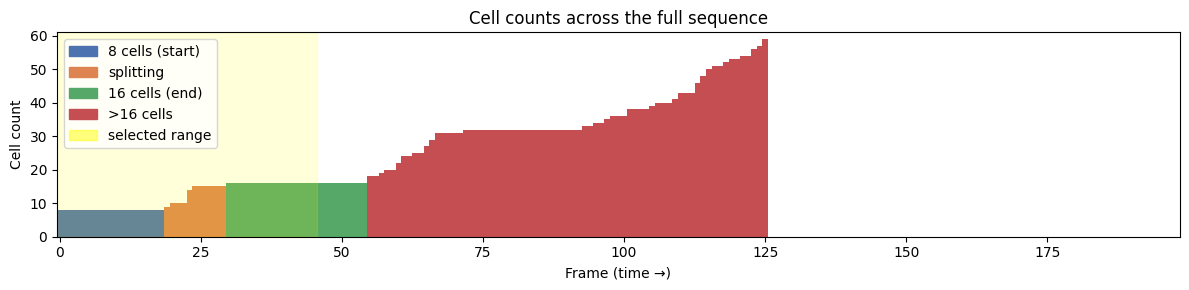

Selected range: frames 0–45  (8 cells → 16 cells)


In [6]:
# Count nonzero-volume nuclei per frame
cell_counts = [
    sum(1 for v in data['volumes'][i] if v > 1e-5)
    for i in range(n_feat_frames)
]

n_start = cell_counts[START_FRAME]   # cells in first frame of selected range
n_end   = cell_counts[END_FRAME]     # cells in last frame

# colour bars relative to the selected stage
def _bar_color(c):
    if   c == n_start:  return '#4C72B0'   # start count  → blue
    elif c <  n_end:    return '#DD8452'   # mid-split    → orange
    elif c == n_end:    return '#55A868'   # end count    → green
    else:               return '#C44E52'   # beyond range → red

colours = [_bar_color(c) for c in cell_counts]

fig, ax = plt.subplots(figsize=(12, 3))
frames  = np.arange(n_feat_frames)
ax.bar(frames, cell_counts, color=colours, width=1.0, edgecolor='none')

# highlight selected frame window
stage_lbl = f'{DATASET} {STAGE}' if DATASET == 'Mouse' else f'{DATASET} 0\u2013{WORM_END_FRAME}'
ax.axvspan(START_FRAME - 0.5, END_FRAME + 0.5, alpha=0.15, color='yellow',
           label=f'{stage_lbl}  frames {START_FRAME}\u2013{END_FRAME}')

legend_elements = [
    mpatches.Patch(color='#4C72B0', label=f'{n_start} cells (start)'),
    mpatches.Patch(color='#DD8452', label='splitting'),
    mpatches.Patch(color='#55A868', label=f'{n_end} cells (end)'),
    mpatches.Patch(color='#C44E52', label=f'>{n_end} cells'),
    mpatches.Patch(color='yellow',  alpha=0.5, label='selected range'),
]
ax.legend(handles=legend_elements, loc='upper left')
ax.set_xlabel('Frame (time \u2192)')
ax.set_ylabel('Cell count')
ax.set_title('Cell counts across the full sequence')
ax.set_xlim(-0.5, n_feat_frames - 0.5)
ax.set_ylim(0, max(cell_counts) + 2)
plt.tight_layout()
plt.show()

print(f'Selected range: frames {START_FRAME}\u2013{END_FRAME}  '
      f'({n_start} cells \u2192 {n_end} cells)')


## 3 — Visualise the initial cells in 3-D

Before running any tracking, let's see where the starting cells are located at the start of our window. Each nucleus is represented by its **centroid** (the average 3-D position of all its voxels).

Frame 0: 8 cells


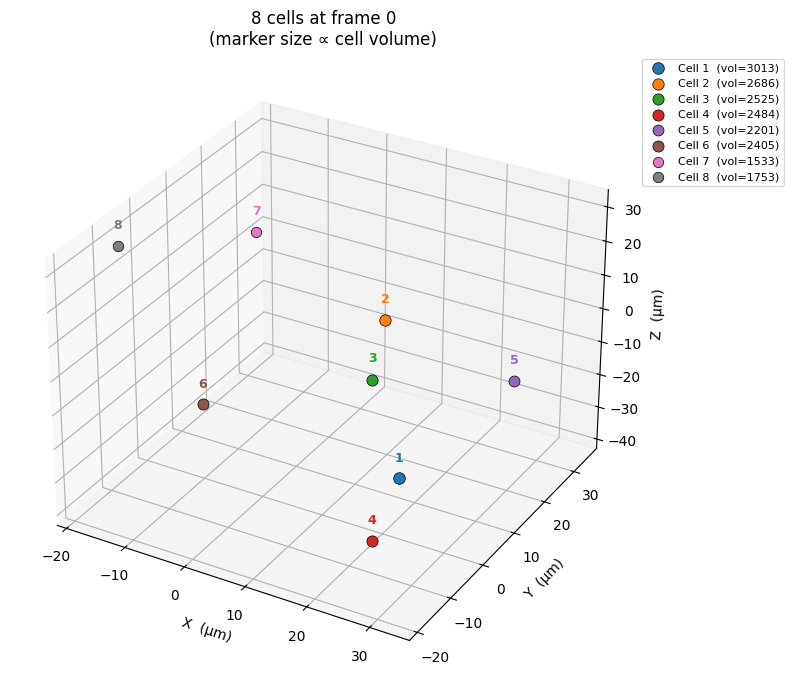

In [7]:
def get_nonzero_cells(frame, data):
    """Return (label, centroid, volume) for every cell with nonzero volume."""
    cells = []
    for i, v in enumerate(data['volumes'][frame]):
        if v > 1e-5:
            cells.append({
                'label':    i + 1,        # 1-based label
                'centroid': data['centroids'][frame][i],   # [z, y, x]
                'volume':   v,
            })
    return cells

init_cells = get_nonzero_cells(START_FRAME, data)
print(f'Frame {START_FRAME}: {len(init_cells)} cells')

CMAP = plt.get_cmap('tab10')

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

for i, cell in enumerate(init_cells):
    z, y, x = cell['centroid']
    # scale marker size by volume
    s = 40 + cell['volume'] / 100
    ax.scatter(x, y, z, s=s, color=CMAP(i), edgecolors='k', linewidths=0.5,
               label=f"Cell {cell['label']}  (vol={int(cell['volume'])})", zorder=3)
    ax.text(x, y, z + 5, str(cell['label']), ha='center', fontsize=9,
            color=CMAP(i), fontweight='bold')

ax.set_xlabel('X  (µm)')
ax.set_ylabel('Y  (µm)')
ax.set_zlabel('Z  (µm)')
ax.set_title(f'{len(init_cells)} cells at frame {START_FRAME}\n(marker size \u221d cell volume)')
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

## 4 — Run Simulated Annealing

We now set up the SA and run it for the selected stage.

### Features and Penalty Functions

Each candidate lineage assignment is scored by a sum of weighted penalty terms. All weights are set in the config file.

---

#### Centroid penalties (`centWt`)

Applied to **every** parent→daughter link.

| Term | Config key | Description |
|---|---|---|
| **CentNoSplit** | `centNoSplitWt` | Squared distance between mother and its single daughter (non-dividing step). Zero cost at distance 0. |
| **centSplitMD** | `centSplitMDWt` | For a dividing cell: squared deviation of the mother→daughter distance from the expected distance `centSplitMDDist`. Applied to each daughter. |
| **centSplitDD** | `centSplitDDWt` | Squared deviation of the daughter–daughter distance from the expected value `centSplitDDDist`. |

The expected distances `centSplitMDDist` and `centSplitDDDist` encode the typical separation between mother and daughters at division (tuned per dataset).

---

#### Volume penalty (`volWt`)

| Term | Config key | Description |
|---|---|---|
| **volNoSplit** | `volNoSplitWt` | Squared mismatch between daughter volume and `volNoSplitMult × mother volume`. Penalises unexpected growth/shrinkage in a non-dividing step. |
| **volSplit** | `volSplitWt` | Squared mismatch between the *sum* of daughter volumes and `volSplitMult × mother volume`. Penalises unphysical total volume change at a division. |

---

#### Division-geometry penalties (split events only)

| Term | Config key | Description |
|---|---|---|
| **Angle of division** | `angWt` | $\lvert \theta - \theta_\text{target} \rvert$ where $\theta$ is the angle at the mother between the two daughter vectors. Target $\approx 156°$ for mouse. |
| **Symmetry of division** | `symWt` | Penalises asymmetry in mother→daughter distances: $\lvert d_1 - d_2 \rvert$. |
| **Aspect ratio** | `aspWt` | Penalises non-spherical daughters (based on the aspect-ratio shape descriptor). |
| **Solidity** | `mdDistWt` | Mother–daughter distance cost. With `mdDistSquared=True` uses $(d^2 - d_\text{ref})$ clamped at zero; otherwise uses $d$ directly. |

---

#### Intensity penalties

| Term | Config key | Description |
|---|---|---|
| **Mean intensity of mother** | `meanIWt` | Penalises mismatch in mean fluorescence intensity between the mother and its daughter(s). |
| **Variance of intensity** | `stdIWt` | Penalises mismatch in intensity standard deviation between mother and daughters. |

---

#### Balance cost (`splitWt`)

**BalanceCost** penalises assignments where a cell has more than two descendants — enforcing the balanced binary-tree constraint. It is proportional to the square of the excess descendant count. Set `splitWt=0` (and `support_split=False`) for worm data where the balanced-tree assumption does not apply.

---

### Temperature schedule

SA accepts a bad move with probability $e^{-\Delta C / T}$. The temperature $T$ drops exponentially from $10^5$ to $10^1$ over `nepochs` epochs. `earlyStopIter=200` stops early if the best cost has not improved in 200 consecutive epochs.

Cells per frame:  6–24: 8    25: 9    26–28: 10    29: 14    30–35: 15    36–51: 16
Tracks start at frame 0
Tracks end at frame   45
 Epoch      Total cost       MthrDst           Sym         Angle        Aspect         MeanI        CentNS         VolNS        VolSpl           Bal
----------------------------------------------------------------------------------------------------------------------------------------------------
   100       8,406,638         2,476           707         7,144           106       -11,681     8,117,615        86,335        36,086        36,000
   200       7,744,030         3,105           579         6,525           134       -11,758     7,392,953        80,626        72,019        20,000
   300       6,486,070         2,655           663         6,781           179       -11,667     6,202,465        72,177        64,247        12,000
   400       5,160,006         2,508           421         6,368           170       -11,634     4,914,150        70,316  

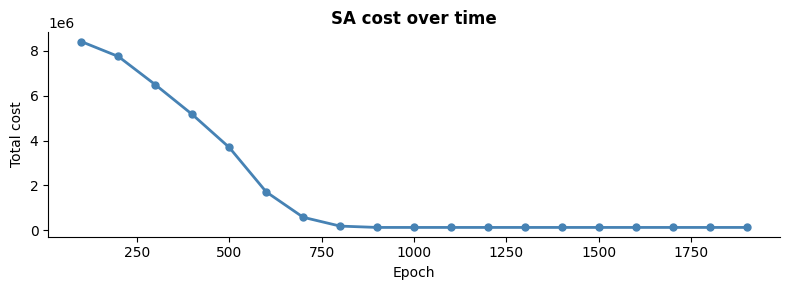

In [8]:
# ── Load precomputed result or run SA ─────────────────────────────────────────

# Frame subsampling (worm with FRAME_STEP > 1)
if FRAME_STEP > 1:
    sa_frames = list(range(START_FRAME, END_FRAME + 1, FRAME_STEP))
    if sa_frames[-1] != END_FRAME:   # ensure final frame is always included
        sa_frames.append(END_FRAME)
    data_sa   = {k: ([v[f] for f in sa_frames] if isinstance(v, list) else v)
                 for k, v in data.items()}
    SA_START, SA_END = 0, len(sa_frames) - 1
    _gt0 = sa_frames[0]  + register_begin_frame
    _gt1 = sa_frames[-1] + register_begin_frame
    print(f'Frame subsampling: {len(sa_frames)} frames '
          f'(feature {sa_frames[0]}–{sa_frames[-1]}, GT {_gt0}–{_gt1})')
else:
    data_sa   = data
    sa_frames = list(range(START_FRAME, END_FRAME + 1))
    SA_START, SA_END = START_FRAME, END_FRAME

nframes_sa = SA_END - SA_START + 1

if USE_PRECOMPUTED and PRECOMPUTED_EXISTS:
    with open(PRECOMPUTED_PATH) as _f:
        sim_graph = json.load(_f)
    print(f'Loaded precomputed result: {PRECOMPUTED_PATH}')
    print(f'  {len(sim_graph["Nodes"])} nodes, {len(sim_graph["Edges"])} edges')
    # Rebuild tracks from sim_graph so downstream cells work
    nucCounts       = []
    list_nuc_labels = {}
    for iframe in range(SA_START, SA_START + nframes_sa):
        vols = np.asarray(data_sa['volumes'][iframe])
        idx  = np.nonzero(vols)[0]
        nucCounts.append(int(idx.shape[0]))
        list_nuc_labels[iframe] = list(idx)
    _runs = []
    for _i, _c in enumerate(nucCounts):
        if _runs and _runs[-1][2] == _c:
            _runs[-1] = (_runs[-1][0], _i, _c)
        else:
            _runs.append((_i, _i, _c))
    _parts = []
    for (_i0, _i1, _c) in _runs:
        _f0, _f1 = sa_frames[_i0] + register_begin_frame, sa_frames[_i1] + register_begin_frame
        _parts.append(f'{_f0}' if _f0 == _f1 else f'{_f0}–{_f1}')
        _parts[-1] += f': {_c}'
    print('Cells per frame:  ' + '    '.join(_parts))
    import math as _math
    ang_target = sa.get('angTarget', 156) * _math.pi / 180
    MyCP = MyCostParams(
        sa['mdDistWt'], sa['symWt'], sa['angWt'], sa['aspWt'],
        sa['meanIWt'], sa['stdIWt'],
        sa['centWt'], sa['centNoSplitWt'], sa['centSplitMDWt'], sa['centSplitDDWt'],
        sa['centSplitMDDist'], sa['centSplitDDDist'],
        sa['volWt'], sa['volNoSplitWt'], sa['volSplitWt'],
        sa['volNoSplitMult'], sa['volSplitMult'],
        sa['splitWt'],
        mdDistSquared = sa.get('mdDistSquared', False),
        mdDistRef     = sa.get('mdDistRef', 0.0),
        angTarget     = ang_target,
        aspTarget     = sa.get('aspTarget', 1.8),
    )
    support_split  = sa.get('support_split', True)
    splitWt        = sa['splitWt']
    anneal_splitWt = splitWt if support_split else None
    FEATURE_LABELS = {
        'mdDistSim': 'Mother–daughter dist', 'symSim': 'Symmetry',
        'angSim': 'Angle of division',       'aspSim': 'Aspect ratio',
        'meanISim': 'Mean intensity',         'centNoSplitSim': 'CentNoSplit',
        'centSplitSim': 'CentSplit (MD+DD)', 'volNoSplitSim': 'VolNoSplit',
        'volSplitSim': 'VolSplit',            'splitSim': 'BalanceCost',
    }
    tracks = sim_anneal.Tracks(nucCounts, supportSplit=support_split)
    tracksInit(tracks, data_sa, SA_START, list_nuc_labels, 0)
    from sim_anneal_utils import tracksInitFromSimGraph as _tifs
    _tifs(tracks, data_sa, data_sa, sim_graph['Nodes'], sim_graph['Edges'], SA_START, start_info=0)
else:
    import io, contextlib

    # ── build nucCounts and list_nuclei_labels ────────────────────────────────
    nucCounts       = []
    list_nuc_labels = {}

    for iframe in range(SA_START, SA_START + nframes_sa):
        vols = np.asarray(data_sa['volumes'][iframe])
        idx  = np.nonzero(vols)[0]
        nucCounts.append(int(idx.shape[0]))
        list_nuc_labels[iframe] = list(idx)

    _runs = []
    for _i, _c in enumerate(nucCounts):
        if _runs and _runs[-1][2] == _c:
            _runs[-1] = (_runs[-1][0], _i, _c)
        else:
            _runs.append((_i, _i, _c))
    _parts = []
    for (_i0, _i1, _c) in _runs:
        _f0, _f1 = sa_frames[_i0] + register_begin_frame, sa_frames[_i1] + register_begin_frame
        _parts.append(f'{_f0}' if _f0 == _f1 else f'{_f0}–{_f1}')
        _parts[-1] += f': {_c}'
    print('Cells per frame:  ' + '    '.join(_parts))

    # ── cost parameters ───────────────────────────────────────────────────────
    import math as _math
    ang_target = sa.get('angTarget', 156) * _math.pi / 180

    MyCP = MyCostParams(
        sa['mdDistWt'], sa['symWt'], sa['angWt'], sa['aspWt'],
        sa['meanIWt'], sa['stdIWt'],
        sa['centWt'], sa['centNoSplitWt'], sa['centSplitMDWt'], sa['centSplitDDWt'],
        sa['centSplitMDDist'], sa['centSplitDDDist'],
        sa['volWt'], sa['volNoSplitWt'], sa['volSplitWt'],
        sa['volNoSplitMult'], sa['volSplitMult'],
        sa['splitWt'],
        mdDistSquared = sa.get('mdDistSquared', False),
        mdDistRef     = sa.get('mdDistRef', 0.0),
        angTarget     = ang_target,
        aspTarget     = sa.get('aspTarget', 1.8),
    )

    support_split  = sa.get('support_split', True)
    splitWt        = sa['splitWt']
    anneal_splitWt = splitWt if support_split else None

    # ── initialise tracks ─────────────────────────────────────────────────────
    tracks = sim_anneal.Tracks(nucCounts, supportSplit=support_split)
    tracksInit(tracks, data_sa, SA_START, list_nuc_labels, 0)
    sim_anneal.tracksShuffle(tracks)
    tracks.validate()

    # ── column definitions for per-checkpoint table ───────────────────────────
    FEATURE_LABELS = {
        'mdDistSim':      'Mother–daughter dist',
        'symSim':         'Symmetry',
        'angSim':         'Angle of division',
        'aspSim':         'Aspect ratio',
        'meanISim':       'Mean intensity',
        'centNoSplitSim': 'CentNoSplit',
        'centSplitSim':   'CentSplit (MD+DD)',
        'volNoSplitSim':  'VolNoSplit',
        'volSplitSim':    'VolSplit',
        'splitSim':       'BalanceCost',
    }

    _COL_ORDER = [
        ('mdDistSim',      'MthrDst',  sa.get('mdDistWt', 0)),
        ('symSim',         'Sym',      sa.get('symWt', 0)),
        ('angSim',         'Angle',    sa.get('angWt', 0)),
        ('aspSim',         'Aspect',   sa.get('aspWt', 0)),
        ('meanISim',       'MeanI',    sa.get('meanIWt', 0)),
        ('centNoSplitSim', 'CentNS',   sa.get('centWt', 0) * sa.get('centNoSplitWt', 0)),
        ('centSplitSim',   'CentSpl',  sa.get('centWt', 0) * max(sa.get('centSplitMDWt', 0), sa.get('centSplitDDWt', 0))),
        ('volNoSplitSim',  'VolNS',    sa.get('volWt', 0) * sa.get('volNoSplitWt', 0)),
        ('volSplitSim',    'VolSpl',   sa.get('volWt', 0) * sa.get('volSplitWt', 0)),
        ('splitSim',       'Bal',      sa.get('splitWt', 0)),
    ]
    active_cols = [(k, abbr) for k, abbr, wt in _COL_ORDER if wt > 0]

    W = 12
    GAP = '  '
    _hdr_left  = f'{"Epoch":>6}  {"Total cost":>14}'
    _hdr_feats = ''.join(GAP + f'{abbr:>{W}}' for _, abbr in active_cols)
    _sep = '-' * (len(_hdr_left) + len(_hdr_feats))
    print(_hdr_left + _hdr_feats)
    print(_sep)

    # ── SA in segments ────────────────────────────────────────────────────────
    REPORT_EVERY      = 100
    EARLY_STOP_EPOCHS = 1000   # stop when cost hasn't improved for this many epochs
    START_T, STOP_T = 1e5, 1e1
    total_epochs = sa['nepochs']
    ratio = (STOP_T / START_T) ** (1.0 / max(total_epochs - 1, 1))

    cost_history     = []
    epoch            = 0
    best_cost_seen   = float('inf')
    no_improve_epochs = 0

    while epoch < total_epochs:
        seg = min(REPORT_EVERY, total_epochs - epoch)
        t0  = START_T * ratio ** epoch
        t1  = START_T * ratio ** (epoch + seg - 1)

        with contextlib.redirect_stdout(io.StringIO()):
            tracks = sim_anneal.anneal(
                tracks, epochs=seg,
                startTemp=t0, stopTemp=t1,
                daughterCostFunc=GeneralCostFunc(MyCP),
                splitWt=anneal_splitWt,
                earlyStopIter=seg + 1,
            )
        epoch += seg

        cost = sim_anneal.tracksCost(
            tracks, daughterCostFunc=GeneralCostFunc(MyCP), splitWt=anneal_splitWt)
        cost_history.append((epoch, cost))

        with contextlib.redirect_stdout(io.StringIO()):
            seg_costs = EvaluateSimCost(tracks, MyCP, splitWt)

        row_left  = f'{epoch:>6d}  {cost:>14,.0f}'
        row_feats = ''.join(GAP + f'{seg_costs.get(k, 0):>{W},.0f}' for k, _ in active_cols)
        print(row_left + row_feats)

        if cost < best_cost_seen - 1.0:
            best_cost_seen    = cost
            no_improve_epochs = 0
        else:
            no_improve_epochs += seg

        if no_improve_epochs >= EARLY_STOP_EPOCHS:
            if anneal_splitWt is not None:
                _bal = sum(
                    anneal_splitWt * max(0.0, ln.kLeaf - 2.0) ** 2
                    for fr in tracks.frames
                    for ln in fr.nuclei
                    if fr.splitRoot
                )
                if _bal > 0:
                    no_improve_epochs = 0
                    continue
            print(f'  → no further improvement, stopping at epoch {epoch}')
            break

    print(_sep)
    print(f'{"":>6}  {cost_history[-1][1]:>12,.0f}  (final)')
    print()

    sim_graph = OutputGraph(tracks, SA_START)

    # ── save result so USE_PRECOMPUTED can load it next run ──────────────────
    if PRECOMPUTED_PATH is not None:
        os.makedirs(os.path.dirname(PRECOMPUTED_PATH), exist_ok=True)
        with open(PRECOMPUTED_PATH, 'w') as _fout:
            json.dump(sim_graph, _fout, indent=2)
        PRECOMPUTED_EXISTS = True
        print(f'Saved → {os.path.basename(PRECOMPUTED_PATH)}')
        print(f'  Set USE_PRECOMPUTED = True to load this result on the next run.')

    # ── cost-vs-epoch chart ───────────────────────────────────────────────────
    epochs_h, costs_h = zip(*cost_history)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(epochs_h, costs_h, 'o-', color='steelblue', linewidth=2, markersize=5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Total cost')
    ax.set_title('SA cost over time', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()



# ── Update data and frame references for downstream cells ─────────────────────
if FRAME_STEP > 1:
    data        = data_sa
    START_FRAME = SA_START
    END_FRAME   = SA_END
    cell_counts = [sum(1 for v in data['volumes'][i] if v > 1e-5)
                   for i in range(len(data['volumes']))]
    print(f'Data remapped to {len(data["volumes"])} subsampled frames')


## 5 — Lineage Construction

A **lineage tree** shows every cell's identity over time. Each row is one eventual leaf cell (one of the 16 final nuclei). Branching points mark **division events**.

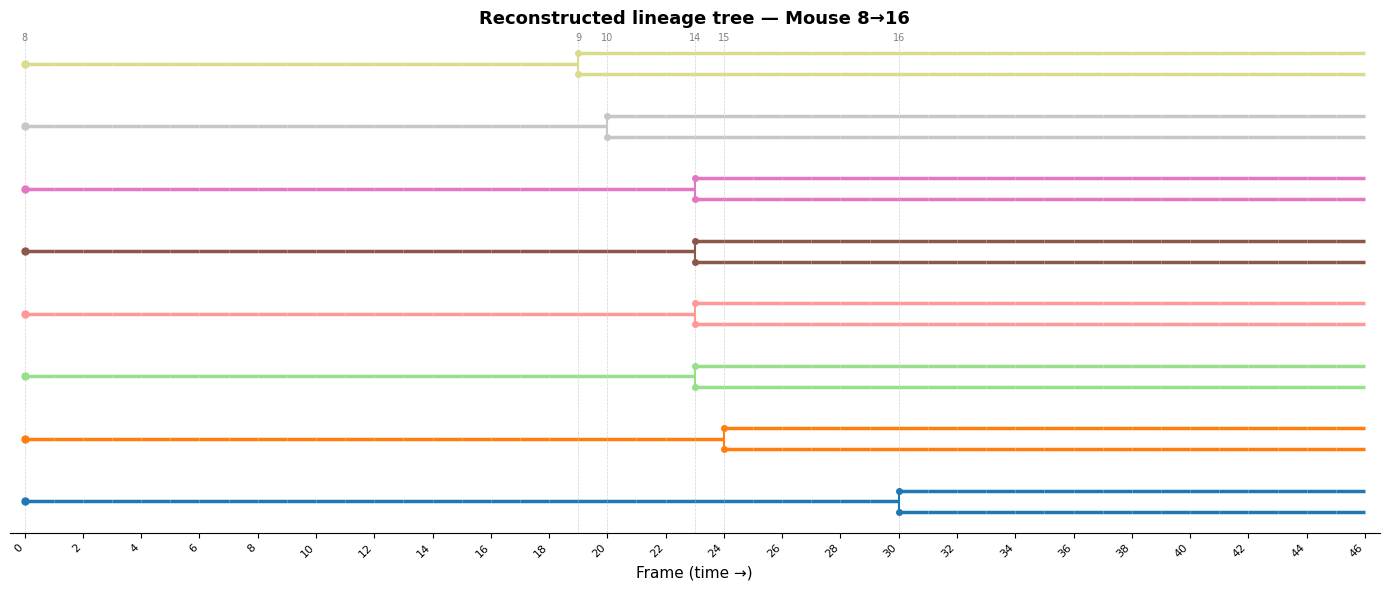

Splits detected: 8


In [9]:
import sys as _sys
_check_dir = os.path.join(PROJECT_DIR, 'CheckResults')
if _check_dir not in _sys.path:
    _sys.path.insert(0, _check_dir)

from plot_lineage import build_layout, assign_root_colors, draw_lineage

# Convert sim_graph to plot_lineage format
pl_nodes = [tuple(n) for n in sim_graph['Nodes']]
pl_edges = [(tuple(s), tuple(t)) for s, t in sim_graph['Edges'] if t[0] > s[0]]

pl_y_pos, pl_children, pl_parents, pl_roots = build_layout(pl_nodes, pl_edges, lineage_gap=1)
root_colors = assign_root_colors(pl_roots, pl_children)

# Expose splits/split_list for downstream cells
splits     = {p: cs for p, cs in pl_children.items() if len(cs) == 2}
split_list = sorted(splits.items(), key=lambda x: x[0][0])

min_frame = min(n[0] for n in pl_nodes)
max_frame = max(n[0] for n in pl_nodes)
n_frames  = max_frame - min_frame + 1
y_vals    = list(pl_y_pos.values())

fig, ax = plt.subplots(figsize=(14, 6))
draw_lineage(pl_nodes, pl_edges, pl_y_pos, pl_children, pl_parents, root_colors, ax, min_frame)

tick_step = max(1, int(np.ceil(n_frames / 25)))
ticks = list(range(0, n_frames + 1, tick_step))
ax.set_xticks(ticks)
ax.set_xticklabels([str(min_frame + i) for i in ticks], rotation=45, ha='right', fontsize=8)
ax.set_yticks([])
ax.set_xlim(-0.5, n_frames + 0.5)
ax.set_ylim(min(y_vals) - 1, max(y_vals) + 1)
ax.set_xlabel('Frame (time →)', fontsize=11)
ax.set_title(f'Reconstructed lineage tree — {CONFIG_LABEL}', fontsize=13, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)

# Cell-count annotations at each count change
_frame_counts = defaultdict(int)
for f, l in pl_nodes:
    _frame_counts[f] += 1
_prev = None
for _frame in sorted(_frame_counts):
    _c = _frame_counts[_frame]
    if _c != _prev:
        ax.text(_frame - min_frame, max(y_vals) + 0.5, str(_c),
                ha='center', va='bottom', fontsize=7, color='gray')
        ax.axvline(_frame - min_frame, color='lightgray', linewidth=0.5,
                   linestyle='--', zorder=0)
        _prev = _c

plt.tight_layout()
plt.show()
print(f'Splits detected: {len(splits)}')

## 6 — 3-D centroid associations at every division frame

For each frame where at least one cell divides, we plot **all nuclei** at both time points together in 3-D:

- **Blue** dots — nuclei in frame *t* (parent frame), labelled by index
- **Red** dots — nuclei in frame *t+1* (daughter frame)
- **Thin grey lines** — normal (non-dividing) parent→child links
- **Thick orange lines** — division edges (one parent → two daughters)

Division frames (5 total): [18, 19, 22, 23, 29]


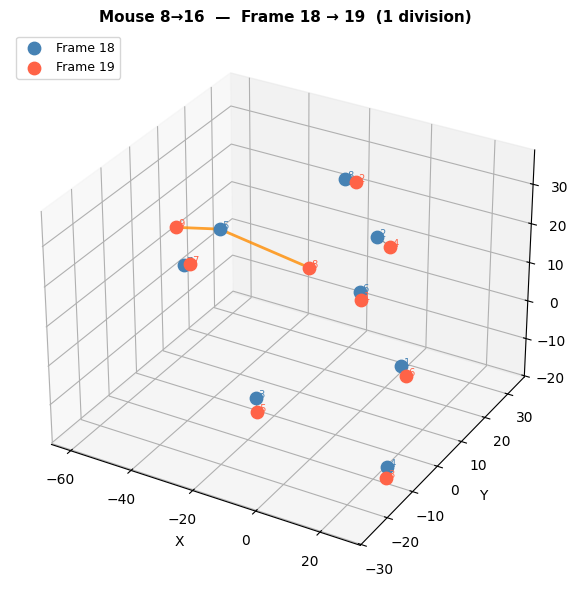

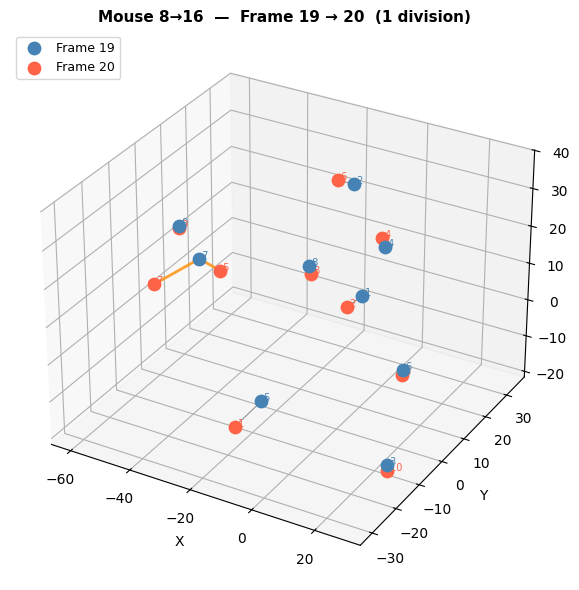

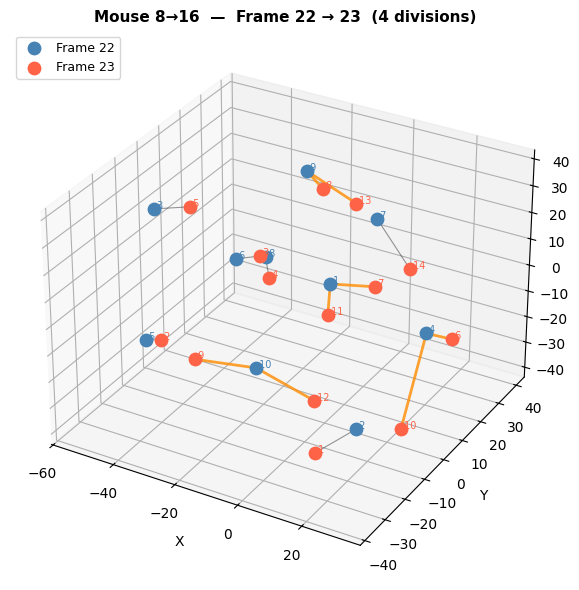

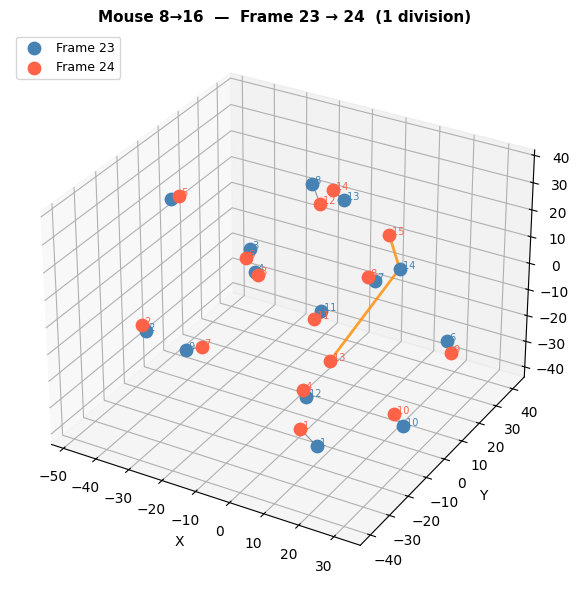

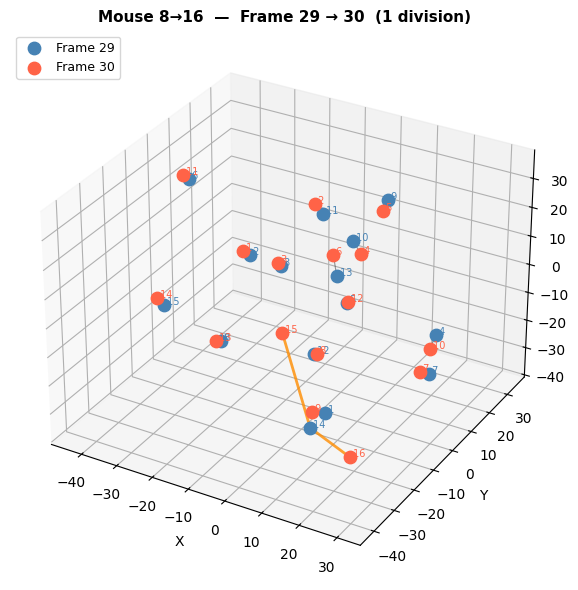

In [12]:
from check_splits import plot_division, find_division_frames

# Build per-frame edge lookup from pl_edges (already computed in tree cell)
edges_by_frame = defaultdict(list)
for src, dst in pl_edges:
    edges_by_frame[src[0]].append((src, dst))

div_frames = find_division_frames(pl_edges)
print(f'Division frames ({len(div_frames)} total): {div_frames}')

config_label = CONFIG_LABEL

# Use data_sa so frame indices match sim_graph node numbers (critical for FRAME_STEP > 1)
for frame_t in div_frames:
    plot_division(frame_t, edges_by_frame[frame_t],
                  data_sa['centroids'], feat_offset=0,
                  out_path=None, config_name=config_label)
    plt.show()


## 7 — Compare with ground truth

We now load the **hand-annotated ground-truth lineage** and compare it with the SA result, frame by frame.

- **1-to-1 accuracy**: what fraction of parent→child assignments match GT exactly?
- **Split accuracy**: for each split, does the SA identify the correct mother cell and correct division frame?

Trimming 1 leading and 0 trailing zero-count GT frames
Tracks start at frame 7
Tracks end at frame   51
1-to-1 accuracy : 519/519  (100.0%)
Split  accuracy : 8/8  (100.0%)

── Split frames (5 total) ─────────────────────────────────
  Frame  18  cell   5:  SA -> [8, 9]   GT -> [8, 9]   [correct]
  Frame  19  cell   7:  SA -> [5, 7]   GT -> [5, 7]   [correct]
  Frame  22  cell   1:  SA -> [7, 11]   GT -> [7, 11]   [correct]
  Frame  22  cell   4:  SA -> [6, 10]   GT -> [6, 10]   [correct]
  Frame  22  cell   9:  SA -> [8, 13]   GT -> [8, 13]   [correct]
  Frame  22  cell  10:  SA -> [9, 12]   GT -> [9, 12]   [correct]
  Frame  23  cell  14:  SA -> [13, 15]   GT -> [13, 15]   [correct]
  Frame  29  cell  14:  SA -> [15, 16]   GT -> [15, 16]   [correct]


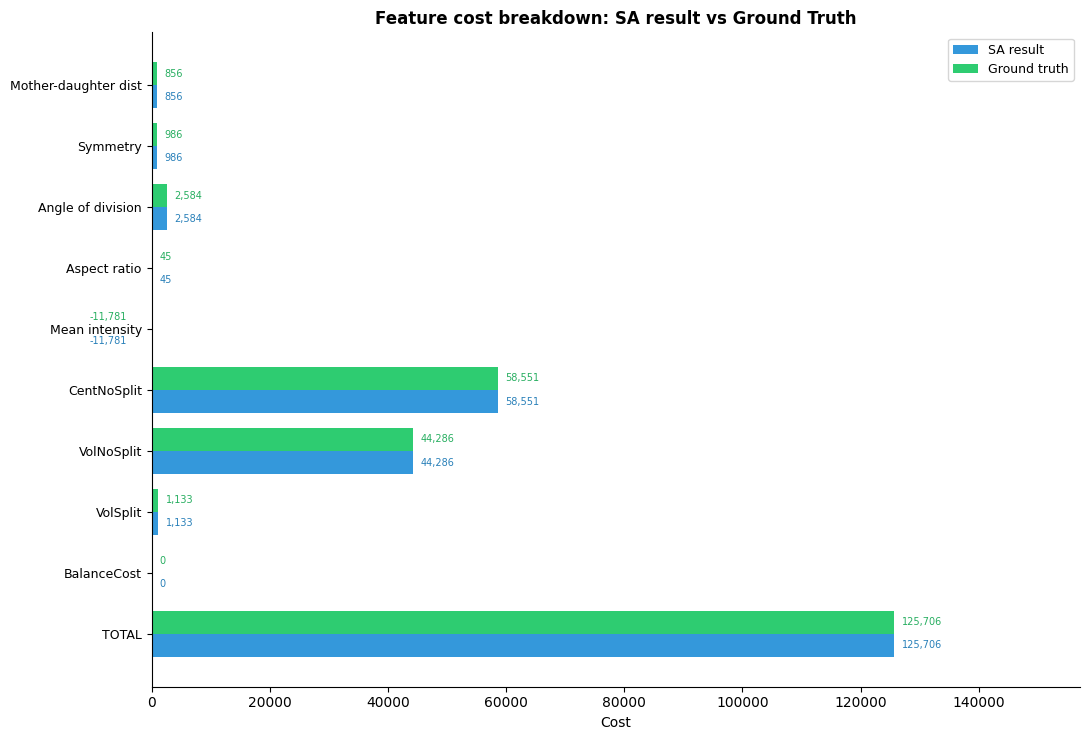

In [13]:
from sim_anneal_utils import tracksInitFromSimGraph, Eval
from NewCostFunction  import MyCostParams, GeneralCostFunc
from EvaluateCost     import EvaluateCost

# ── load raw GT ───────────────────────────────────────────────────────────────
GT_PATH = os.path.join(DATA_DIR, 'GroundTruth', 'LineageGraph.json')
with open(GT_PATH) as f:
    gt_raw = json.load(f)
if 'G_based_on_nn' in gt_raw:
    gt_raw = gt_raw['G_based_on_nn']

# =============================================================================
if FRAME_STEP > 1:
# =============================================================================
    # For frame-skipped runs we bypass tracksInitFromGT entirely.
    # Compose FRAME_STEP consecutive GT steps into a mapping
    # (subsampled_k, src_label) -> frozenset of dst_labels,
    # then compare against the SA sim_graph edges (also as sets).
    # Using sets is essential: a dividing cell produces 2 daughters and
    # both sides must agree on the full daughter set, not just one.

    print(f'Building {FRAME_STEP}-step GT associations ...')

    # Full 1-step GT map: all daughters for dividing cells
    _gt_step_all = {}
    for e in gt_raw['Edges']:
        n0, n1 = e['EndNodes']
        key = (int(n0[:3]), int(n0[-3:]))
        _gt_step_all.setdefault(key, []).append((int(n1[:3]), int(n1[-3:])))

    _gt_labels = {}
    for node in gt_raw['Nodes']:
        nm = node['Name']
        _gt_labels.setdefault(int(nm[:3]), set()).add(int(nm[-3:]))

    def _compose_gt(start_f, start_l, steps):
        """BFS over GT edges for `steps` steps; return frozenset of final labels."""
        frontier = [(start_f, start_l)]
        for _ in range(steps):
            nxt = []
            for (cf, cl) in frontier:
                nxt.extend(_gt_step_all.get((cf, cl), []))
            if not nxt:
                return None
            frontier = nxt
        return frozenset(cl for _, cl in frontier)

    # Build gt_fwd: (k, src_label) -> frozenset of dst_labels
    # sa_frames[k] is a feature frame index; GT nodes use GT frame = feature + register_begin_frame
    gt_fwd = {}
    n_broken = 0
    for k in range(len(sa_frames) - 1):
        orig_f    = sa_frames[k]
        gt_orig_f = orig_f + register_begin_frame
        for l0 in sorted(_gt_labels.get(gt_orig_f, set())):
            dst = _compose_gt(gt_orig_f, l0, FRAME_STEP)
            if dst is not None:
                gt_fwd[(k, l0)] = dst
            else:
                n_broken += 1

    sfx = f'  ({n_broken} chains incomplete/skipped)' if n_broken else ''
    print(f'  {len(gt_fwd)} GT associations over {len(sa_frames)-1} transitions{sfx}')

    # SA forward map: (k, src_label) -> frozenset of dst_labels
    sa_fwd = {}
    for edge in sim_graph['Edges']:
        src, dst = edge[0], edge[1]
        if dst[0] > src[0]:
            sa_fwd.setdefault((src[0], src[1]), set()).add(dst[1])
    sa_fwd = {k: frozenset(v) for k, v in sa_fwd.items()}

    # Compare
    good = total = 0
    good_splits = total_splits = 0
    errors = []
    for (k, l), gt_d in sorted(gt_fwd.items()):
        sa_d = sa_fwd.get((k, l))
        if sa_d is not None:
            total += 1
            is_split = len(gt_d) > 1
            if is_split:
                total_splits += 1
            if sa_d == gt_d:
                good += 1
                if is_split:
                    good_splits += 1
            else:
                errors.append((k, l, sa_d, gt_d))

    print(f'\n1-to-1 accuracy : {good}/{total}  ({100*good/max(total,1):.1f}%)')
    print(f'Split  accuracy : {good_splits}/{total_splits}  ({100*good_splits/max(total_splits,1):.1f}%)')

    # Per-transition summary
    print(f'\n── Per-transition accuracy ──────────────────────────────────')
    for k in range(len(sa_frames) - 1):
        pairs = [(l, gt_d) for (kk, l), gt_d in gt_fwd.items() if kk == k]
        if not pairs:
            continue
        good_k  = sum(1 for l, gt_d in pairs if sa_fwd.get((k, l)) == gt_d)
        total_k = len(pairs)
        marker  = ' ' if good_k == total_k else '*'
        print(f'  {marker} k={k:2d}  orig {sa_frames[k]:3d}→{sa_frames[k+1]:3d}:  ' +
              f'{good_k}/{total_k}  ({100*good_k/max(total_k,1):.0f}%)')

    # Disagreements
    if errors:
        print(f'\n── {len(errors)} disagreement{"s" if len(errors)!=1 else ""} ───────────────────────────────')
        for k, l, sa_d, gt_d in errors:
            print(f'  Frame k={k:2d}  (orig {sa_frames[k]:3d}→{sa_frames[k+1]:3d})  '
                  f'cell {l:4d}:  SA→{sorted(sa_d)}   GT→{sorted(gt_d)}   [DISAGREE]')
    else:
        print('\nAll tracked cells agree with GT!')

    # Mark downstream cells that need gt_tracks/result_tracks as unavailable
    eval_nframes  = None
    result_tracks = None
    gt_tracks     = None

# =============================================================================
else:
# =============================================================================
    gt_start = START_FRAME + register_begin_frame
    gt_end   = END_FRAME   + register_begin_frame

    gt_nodes_w = [n for n in gt_raw['Nodes']
                  if gt_start <= int(n['Name'][:3]) <= gt_end]
    gt_edges_w = [e for e in gt_raw['Edges']
                  if gt_start <= int(e['EndNodes'][0][:3]) <= gt_end
                  and gt_start <= int(e['EndNodes'][1][:3]) <= gt_end]

    [gt_nucCounts, list_nuclei_labels] = GetNucleiPerFrame(
        gt_start, gt_end, gt_nodes_w, number_of_excludes_per_frame=0)

    skip = next((i for i, c in enumerate(gt_nucCounts) if c > 0), 0)
    trim = next((i for i, c in enumerate(reversed(gt_nucCounts)) if c > 0), 0)
    if skip > 0 or trim > 0:
        print(f'Trimming {skip} leading and {trim} trailing zero-count GT frames')
        gt_start += skip
        gt_end   -= trim
        gt_nucCounts = gt_nucCounts[skip: len(gt_nucCounts) - trim if trim else None]

    eval_start   = START_FRAME + skip
    eval_end     = END_FRAME   - trim
    eval_nframes = eval_end - eval_start + 1
    gt_init_start = gt_start
    gt_start_info = register_begin_frame

    gt_tracks = sim_anneal.Tracks(gt_nucCounts, supportSplit=support_split)
    tracksInitFromGT(gt_tracks, data, data, gt_edges_w,
                     gt_init_start, list_nuclei_labels,
                     exclude_labels={}, start_info=gt_start_info)
    gt_tracks.validate(computeKLeaf=support_split)

    res_nucCounts = [cell_counts[f] for f in range(eval_start, eval_end + 1)]
    result_tracks = sim_anneal.Tracks(res_nucCounts, supportSplit=support_split)
    tracksInitFromSimGraph(result_tracks, data, data,
                           sim_graph['Nodes'], sim_graph['Edges'],
                           eval_start, start_info=0)
    result_tracks.validate(computeKLeaf=support_split)

    with contextlib.redirect_stdout(io.StringIO()):
        [good_1to1, total_1to1,
         good_splits, total_splits] = Eval(eval_nframes, result_tracks, gt_tracks, eval_start)
    print(f'1-to-1 accuracy : {good_1to1}/{total_1to1}  '
          f'({100*good_1to1/max(total_1to1,1):.1f}%)')
    print(f'Split  accuracy : {good_splits}/{total_splits}  '
          f'({100*good_splits/max(total_splits,1):.1f}%)')

    def _splits_and_edges(tracks, start_frame, n_frames):
        splits = {}
        edges  = defaultdict(list)
        for iframe in range(n_frames):
            abs_f = start_frame + iframe
            for nuc in tracks.frames[iframe].nuclei:
                d0, d1 = nuc.daughters[0], nuc.daughters[1]
                if d0 is not None:
                    edges[abs_f].append(((abs_f, nuc.label), (abs_f + 1, d0.label)))
                if d1 is not None:
                    edges[abs_f].append(((abs_f, nuc.label), (abs_f + 1, d1.label)))
                if d0 is not None and d1 is not None:
                    splits.setdefault(abs_f, {})[nuc.label] = sorted([d0.label, d1.label])
        return splits, edges

    res_splits_map, res_edges = _splits_and_edges(result_tracks, eval_start, eval_nframes)
    gt_splits_map,  gt_edges  = _splits_and_edges(gt_tracks,    eval_start, eval_nframes)
    all_split_frames = sorted(set(res_splits_map) | set(gt_splits_map))

    if not all_split_frames:
        print('\nNo cell divisions in this frame range.')
    else:
        print(f'\n── Split frames ({len(all_split_frames)} total) ─────────────────────────────────')
        for frame_t in all_split_frames:
            res_f = res_splits_map.get(frame_t, {})
            gt_f  = gt_splits_map.get(frame_t, {})
            for mother in sorted(set(res_f) | set(gt_f)):
                res_d = res_f.get(mother)
                gt_d  = gt_f.get(mother)
                if res_d is not None and gt_d is not None:
                    correct = (res_d == gt_d)
                    marker  = 'correct' if correct else 'DISAGREE'
                    print(f'  Frame {frame_t:3d}  cell {mother:3d}:  '
                          f'SA -> {res_d}   GT -> {gt_d}   [{marker}]')
                    if not correct:
                        plot_division(frame_t, gt_edges[frame_t], data['centroids'],
                                      feat_offset=0, out_path=None,
                                      config_name=f'GT  --  {DATASET}  frame {frame_t}')
                        plt.show()
                        plot_division(frame_t, res_edges[frame_t], data['centroids'],
                                      feat_offset=0, out_path=None,
                                      config_name=f'SA result  --  {DATASET}  frame {frame_t}')
                        plt.show()
                elif gt_d is not None:
                    print(f'  Frame {frame_t:3d}  cell {mother:3d}:  '
                          f'SA -> (no split)   GT -> {gt_d}   [MISSED]')
                else:
                    print(f'  Frame {frame_t:3d}  cell {mother:3d}:  '
                          f'SA -> {res_d}   GT -> (no split)   [EXTRA]')

    with contextlib.redirect_stdout(io.StringIO()):
        eval_costs = EvaluateCost(result_tracks, gt_tracks, MyCP, splitWt)

    PAIR_LABELS = {
        ('mdDistSim',      'mdDistGT'):      'Mother-daughter dist',
        ('symSim',         'symGT'):         'Symmetry',
        ('angSim',         'angGT'):         'Angle of division',
        ('aspSim',         'aspGT'):         'Aspect ratio',
        ('meanISim',       'meanIGT'):       'Mean intensity',
        ('centNoSplitSim', 'centNoSplitGT'): 'CentNoSplit',
        ('centSplitSim',   'centSplitGT'):   'CentSplit (MD+DD)',
        ('volNoSplitSim',  'volNoSplitGT'):  'VolNoSplit',
        ('volSplitSim',    'volSplitGT'):    'VolSplit',
        ('splitSim',       'splitGT'):       'BalanceCost',
        ('FullSim',        'FullGT'):        'TOTAL',
    }
    pairs = [(sk, gk, lbl) for (sk, gk), lbl in PAIR_LABELS.items()
             if sk in eval_costs and gk in eval_costs]
    feat_labels = [lbl for _, _, lbl in pairs]
    sa_vals  = [eval_costs[sk] for sk, _, _ in pairs]
    gt_vals  = [eval_costs[gk] for _, gk, _ in pairs]

    x = np.arange(len(pairs))
    w = 0.38
    fig, ax = plt.subplots(figsize=(11, 0.6 * len(pairs) + 1.5))
    bars_sa = ax.barh(x + w/2, sa_vals, height=w, label='SA result', color='#3498DB')
    bars_gt = ax.barh(x - w/2, gt_vals, height=w, label='Ground truth', color='#2ECC71')
    ax.set_yticks(x)
    ax.set_yticklabels(feat_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Cost')
    ax.set_title('Feature cost breakdown: SA result vs Ground Truth', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    max_val = max(sa_vals + gt_vals) if sa_vals + gt_vals else 1
    for bar, v in zip(bars_sa, sa_vals):
        ax.text(bar.get_width() + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:,.0f}', va='center', fontsize=7, color='#2980B9')
    for bar, v in zip(bars_gt, gt_vals):
        ax.text(bar.get_width() + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:,.0f}', va='center', fontsize=7, color='#27AE60')
    ax.set_xlim(0, max_val * 1.25)
    plt.tight_layout()
    plt.show()


## 8 — Per-frame accuracy bar chart

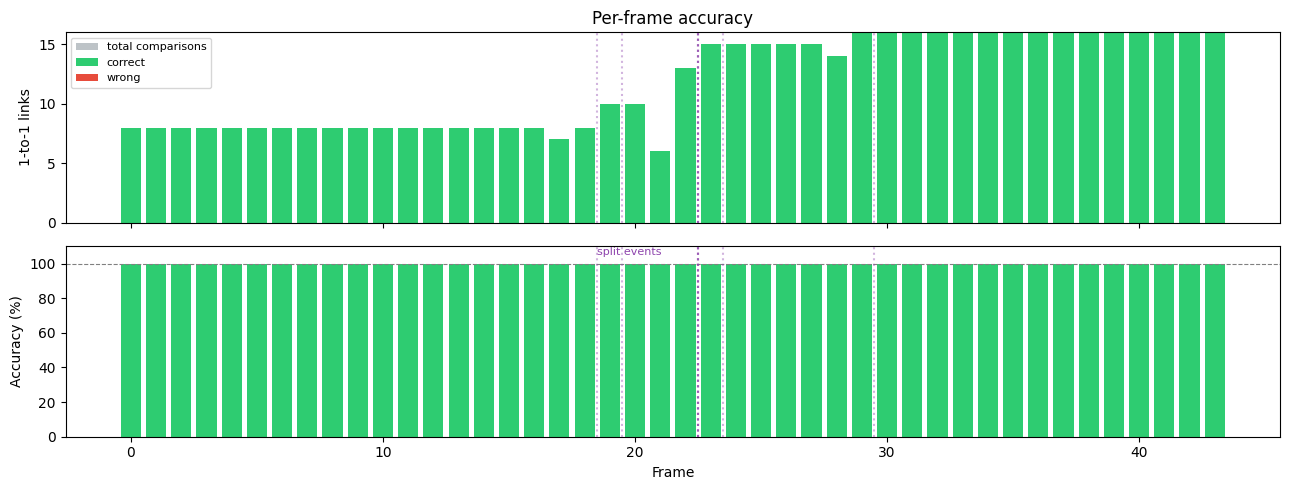

Overall 1-to-1 accuracy: 519/519 = 100.0%


In [14]:
if FRAME_STEP > 1:
    # Per-transition accuracy from gt_fwd / sa_fwd built in the GT eval cell above
    trans_frames, trans_match, trans_total = [], [], []
    for k in range(len(sa_frames) - 1):
        pairs = [(l, gt_d) for (kk, l), gt_d in gt_fwd.items() if kk == k]
        if not pairs:
            continue
        good_k = sum(1 for l, gt_d in pairs if sa_fwd.get((k, l)) == gt_d)
        trans_frames.append(sa_frames[k])
        trans_match.append(good_k)
        trans_total.append(len(pairs))

    trans_frames = np.array(trans_frames)
    trans_match  = np.array(trans_match)
    trans_total  = np.array(trans_total)
    trans_acc    = trans_match / np.maximum(trans_total, 1)

    fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

    axes[0].bar(trans_frames, trans_total, color='#BDC3C7', label='total comparisons', width=FRAME_STEP * 0.7)
    axes[0].bar(trans_frames, trans_match, color='#2ECC71', label='correct', width=FRAME_STEP * 0.7)
    axes[0].bar(trans_frames, trans_total - trans_match,
                bottom=trans_match, color='#E74C3C', label='wrong', width=FRAME_STEP * 0.7)
    for f, good, tot in zip(trans_frames, trans_match, trans_total):
        if tot > 0 and good < tot:
            axes[0].text(f, tot + 0.1, f'{good}/{tot}', ha='center', fontsize=7, color='#C0392B')
    axes[0].set_ylabel('assignments')
    axes[0].legend(fontsize=8)
    axes[0].set_title(f'Per-transition accuracy  (every {FRAME_STEP} frames)')

    axes[1].bar(trans_frames, trans_acc * 100,
                color=['#2ECC71' if a == 1.0 else '#E74C3C' for a in trans_acc],
                width=FRAME_STEP * 0.7)
    axes[1].axhline(100, linestyle='--', color='gray', linewidth=0.8)
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_xlabel('Source frame')
    axes[1].set_ylim(0, 110)
    axes[1].set_xticks(trans_frames)
    axes[1].set_xticklabels([f'{f}→{f+FRAME_STEP}' for f in trans_frames],
                             rotation=45, ha='right', fontsize=8)

    plt.tight_layout()
    plt.show()

    overall = trans_match.sum() / max(trans_total.sum(), 1)
    print(f'Overall accuracy: {trans_match.sum()}/{trans_total.sum()} = {overall*100:.1f}%')

else:
    # Compute per-frame 1-to-1 accuracy by comparing tracks frame by frame
    from sim_anneal_utils import Eval as _Eval
    import io, contextlib
    
    # Re-run Eval capturing per-frame output (Eval prints to stdout)
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        _Eval(eval_nframes, result_tracks, gt_tracks, START_FRAME)
    output = buf.getvalue()
    
    # Parse: lines like "Frame  X  has 1-1 matches  N  out of  M"
    frame_nums, frame_match, frame_total = [], [], []
    for line in output.splitlines():
        if 'has 1-1 matches' in line:
            parts = line.split()
            frame_nums.append(int(parts[1]))
            frame_match.append(int(parts[5]))
            frame_total.append(int(parts[8]))
    
    frame_nums   = np.array(frame_nums)
    frame_match  = np.array(frame_match)
    frame_total  = np.array(frame_total)
    frame_acc    = frame_match / np.maximum(frame_total, 1)
    
    fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    
    # top: absolute matches
    axes[0].bar(frame_nums, frame_total, color='#BDC3C7', label='total comparisons')
    axes[0].bar(frame_nums, frame_match, color='#2ECC71', label='correct')
    wrong = frame_total - frame_match
    axes[0].bar(frame_nums, wrong, bottom=frame_match, color='#E74C3C', label='wrong')
    for f, good, tot in zip(frame_nums, frame_match, frame_total):
        if tot > 0 and good < tot:
            axes[0].text(f, tot + 0.1, f'{good}/{tot}', ha='center', fontsize=7, color='#C0392B')
    axes[0].set_ylabel('1-to-1 links')
    axes[0].legend(fontsize=8)
    axes[0].set_title('Per-frame accuracy')
    
    # bottom: proportion
    axes[1].bar(frame_nums, frame_acc * 100,
                color=['#2ECC71' if a == 1.0 else '#E74C3C' for a in frame_acc])
    axes[1].axhline(100, linestyle='--', color='gray', linewidth=0.8)
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_xlabel('Frame')
    axes[1].set_ylim(0, 110)
    
    # mark split frames
    for (f_m, _) in splits:
        for ax in axes:
            ax.axvline(f_m + 0.5, color='#8E44AD', alpha=0.4, linewidth=1.5,
                       linestyle=':')
    axes[1].text(split_list[0][0][0] + 0.5, 105, 'split events',
                 color='#8E44AD', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    overall = frame_match.sum() / max(frame_total.sum(), 1)
    print(f'Overall 1-to-1 accuracy: {frame_match.sum()}/{frame_total.sum()} '
          f'= {overall*100:.1f}%')

## Summary

In this tutorial we:
1. Loaded cell features (centroids, volumes, shapes) from a time-lapse microscopy sequence
2. Ran **simulated annealing** to reconstruct a cell lineage
3. Visualised the reconstructed lineage as a **tree** and inspected the **3-D division geometry**
4. Compared against hand-annotated ground truth

---

## Try it yourself

Go back to the [**Configuration**](#Configuration) cell, change `CONFIG` to any of the options in the
table, then **Run All Cells**:

| `CONFIG` | Dataset | Stage | Frame sampling |
|---|---|---|---|
| `'Mouse_8to16'` | Mouse | 8→16 | every frame |
| `'Mouse_8to16_step2'` | Mouse | 8→16 | every other frame |
| `'Mouse_16to32'` | Mouse | 16→32 | every frame |
| `'Mouse_32to64'` | Mouse | 32→64 | every frame |
| `'Worm'` | C. elegans | — | every frame |
| `'Worm_step2'` | C. elegans | — | every other frame |

Set `USE_PRECOMPUTED = True` to load a previously saved result instead of re-running SA.
